In [5]:
import random
import networkx as nx
from generator import GraphGenerator

## Complete Graph

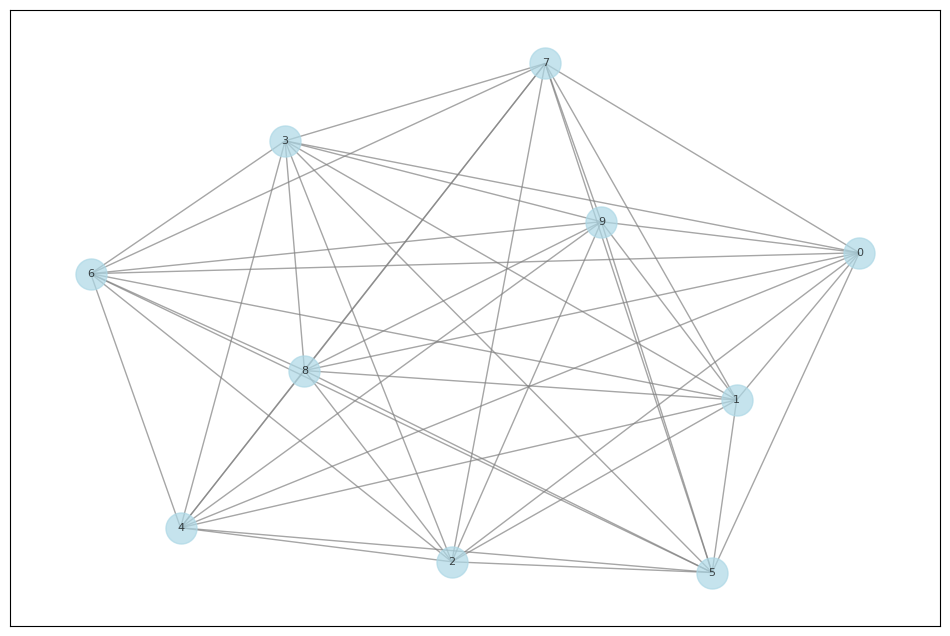

In [6]:
class CompleteGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes
        """
        self.graph = nx.complete_graph(n)


generator = CompleteGraph()
generator.generate_graph(10)
generator.visualise()

## Weighted Graph

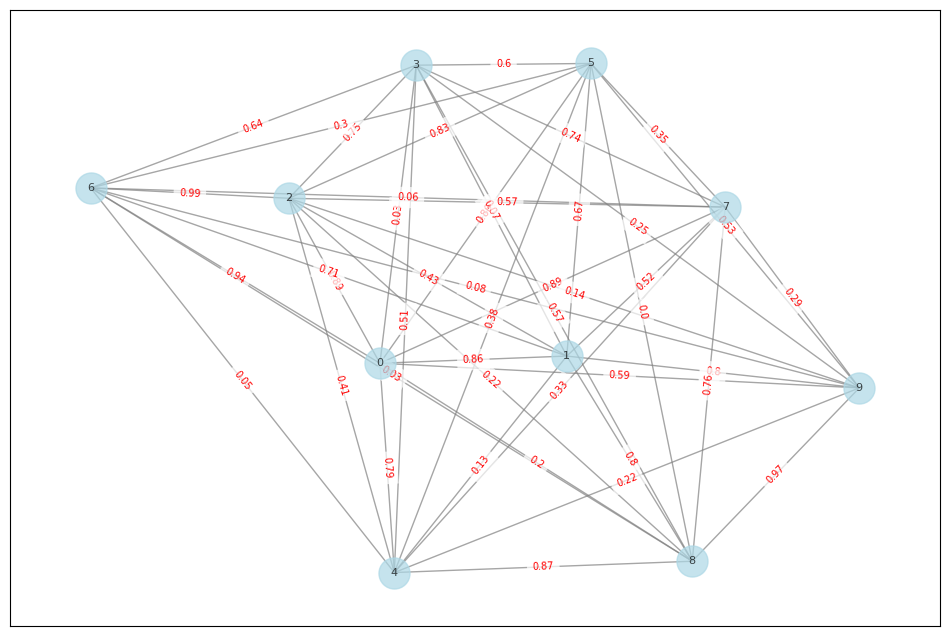

In [7]:
class WeightedGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes, with random weights
        """
        self.graph = nx.complete_graph(n)

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = WeightedGraph()
generator.generate_graph(10)
generator.visualise()

## Barabási-Albert Graph

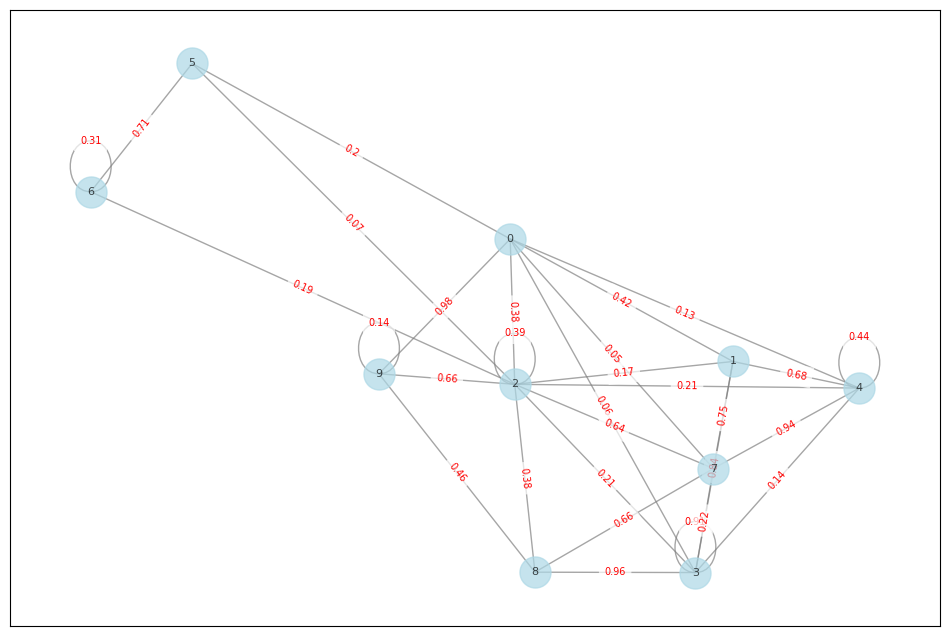

In [8]:
class BarbasiAlbertGraph(GraphGenerator):
    def generate_graph(self, n, m=2, community_prob=0.3, weight_range=(1, 10)):
        """
        Generates a realistic social network graph with:
        - Scale-free properties (Barabási-Albert model)
        - Community structure (random clustering)
        - Weighted edges (interaction strength)

        Args:
            n: Number of nodes.
            m: Number of edges each new node forms (preferential attachment).
            community_prob: Probability of within-community connections.
            weight_range: Range for random edge weights.
        """
        self.graph = nx.barabasi_albert_graph(n, m)

        for u, v in self.graph.edges():
            if random.random() < community_prob:
                for _ in range(2):
                    new_node = random.choice(list(self.graph.neighbors(u)))
                    if not self.graph.has_edge(new_node, v):
                        self.graph.add_edge(new_node, v)

        # Assign random weights to edges to mimic interaction frequency
        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = BarbasiAlbertGraph()
generator.generate_graph(10)
generator.visualise()